# LCEL (LangChain Expression Language)
- LCEL은 LangChain에서 **체인(Chain)** 을 선언적으로 구성하기 위한 언어입니다.

### 주요 특징
- 선언적 구성: 작업의 순서와 흐름을 명시적으로 정의하여, 복잡한 로직을 간결하게 표현할 수 있습니다.
- 파이프 연산자(|) 지원: Unix의 파이프처럼, 함수의 출력을 다음 함수의 입력으로 전달하여 체인을 구성합니다.

> 코드 예제 
```ini
chain = prompt | llm | parser
```

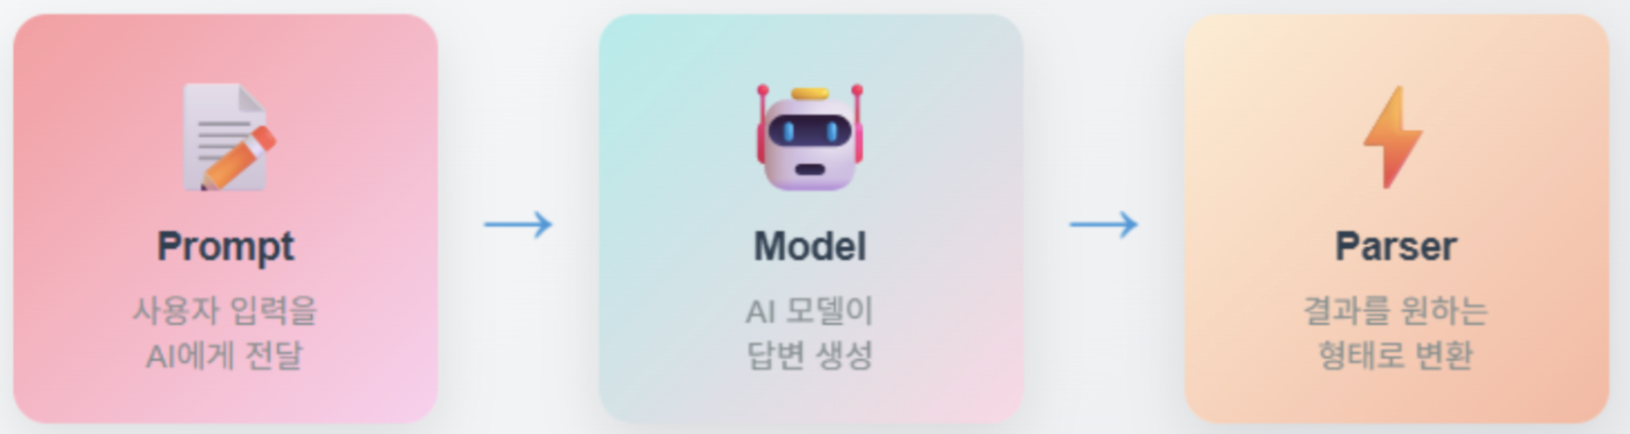

# 병렬 체인 (Parallel Chains)
- 여러 체인을 동시에 실행하여 다양한 관점의 답변을 얻을 수 있습니다.

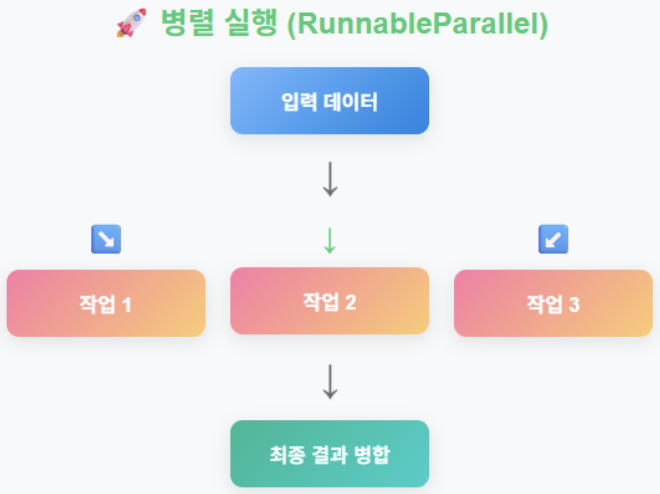

# Model

## [Groq API Key](https://console.groq.com/keys)

In [1]:
from dotenv import load_dotenv

# 환경변수 로드
load_dotenv()

True

## LLM

In [2]:
from langchain_groq import ChatGroq

# 정확한 모델 (Precise Model)
# - temperature 낮음 (0.1): 일관되고 정확한 답변
model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.1,
    model_kwargs={
        "top_p":1.0,                     # nucleus sampling (0.8~0.95 권장)
        "frequency_penalty":0.0,         # 반복 억제
        "presence_penalty":0.0,          # 새로운 아이디어 유도
    },
    max_tokens=2000
)

# Parser

In [3]:
from langchain_core.output_parsers import StrOutputParser

# OutputParser 설정
output_parser = StrOutputParser()

# 장점을 답변하는 체인 생성하기

In [4]:
from langchain_core.prompts import PromptTemplate

pros_prompt = PromptTemplate.from_template(
    template="""
        {topic}의 장점들을 나열해주세요.
    """
)

In [5]:
pros_chain = pros_prompt | model | output_parser

In [6]:
pros_chain

PromptTemplate(input_variables=['topic'], input_types={}, partial_variables={}, template='\n        {topic}의 장점들을 나열해주세요.\n    ')
| ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x1099d6510>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1099d7230>, model_name='openai/gpt-oss-120b', temperature=0.1, model_kwargs={'top_p': 1.0, 'frequency_penalty': 0.0, 'presence_penalty': 0.0}, groq_api_key=SecretStr('**********'), max_tokens=2000)
| StrOutputParser()

# 단점을 답변하는 체인 생성하기

In [7]:
cons_prompt = PromptTemplate.from_template(
    template="""
        {topic}의 단점들을 나열해주세요.
    """
)

In [8]:
cons_chain = cons_prompt | model | output_parser

In [9]:
cons_chain

PromptTemplate(input_variables=['topic'], input_types={}, partial_variables={}, template='\n        {topic}의 단점들을 나열해주세요.\n    ')
| ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x1099d6510>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1099d7230>, model_name='openai/gpt-oss-120b', temperature=0.1, model_kwargs={'top_p': 1.0, 'frequency_penalty': 0.0, 'presence_penalty': 0.0}, groq_api_key=SecretStr('**********'), max_tokens=2000)
| StrOutputParser()

# 전반적인 요약을 답변하는 체인 생성하기

In [10]:
summary_prompt = PromptTemplate.from_template(
    template="""
        {topic}의 대한 전반적인 요약을 해주세요.
    """
)

In [11]:
summary_chain = summary_prompt | model | output_parser

In [12]:
summary_chain

PromptTemplate(input_variables=['topic'], input_types={}, partial_variables={}, template='\n        {topic}의 대한 전반적인 요약을 해주세요.\n    ')
| ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x1099d6510>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1099d7230>, model_name='openai/gpt-oss-120b', temperature=0.1, model_kwargs={'top_p': 1.0, 'frequency_penalty': 0.0, 'presence_penalty': 0.0}, groq_api_key=SecretStr('**********'), max_tokens=2000)
| StrOutputParser()

# RunnableParallel 체인 생성하기 

In [13]:
from langchain_core.runnables import RunnableParallel

# 각 체인들의 input_variables의 값이 똑같아야함!!!
parallel_chain = RunnableParallel({
    "pros": pros_chain,             # 긍정 
    "cons": cons_chain,             # 부정
    "summary": summary_chain        # 요약
})

In [14]:
# 병렬 실행
results = parallel_chain.invoke({"topic": "원격근무"})

In [15]:
results.keys()

dict_keys(['pros', 'cons', 'summary'])

In [16]:
print("=== 장점 ===")
print(results["pros"])

=== 장점 ===
원격근무(재택근무)의 주요 장점들을 아래와 같이 정리해 보았습니다.

| 구분 | 장점 | 구체적인 내용 |
|------|------|----------------|
| **시간·생활** | **유연한 근무시간** | 출퇴근 시간에 얽매이지 않아 개인 일정(가족·취미·학습 등)과 업무를 조율 가능 |
| | **통근 스트레스 감소** | 출퇴근 교통·혼잡, 대중교통 비용·시간 절감, 피로도 감소 |
| | **워크‑라이프 밸런스 향상** | 집에서 바로 업무와 일상 생활을 전환할 수 있어 삶의 질 개선 |
| **생산성·효율** | **집중도 향상** | 사무실의 잡음·방해 요소가 적어 집중 업무에 전념 가능(개인에 따라 차이) |
| | **업무 환경 맞춤화** | 개인이 선호하는 책상·조명·온도 등 최적의 작업 환경을 직접 구성 |
| | **시간 절약** | 통근에 쓰던 시간을 업무 혹은 자기계발에 활용 가능 |
| **비용·경제** | **교통·식비 절감** | 출퇴근 교통비, 점심 외식비, 사무실 복리후생 비용 절감 |
| | **주거·생활비 절감** | 도심 고가 주거 대신 교외·도시 외 지역에서도 거주 가능 |
| | **기업 비용 절감** | 사무실 임대·전기·청소· 시설 관리 등 운영비 절감 |
| **인재·조직** | **채용 범위 확대** | 지리적 제약 없이 전국·전 세계 인재를 채용 가능 |
| | **다양성·포용성 강화** | 다양한 배경·생활 패턴을 가진 인재가 참여하기 쉬움 |
| | **직원 만족도· 유지율 상승** | 원격 근무를 선호하는 직원들의 만족도가 높아 이직률 감소 |
| **환경·사회** | **탄소 배출 감소** | 통근 차량 이용 감소로 교통 관련 탄소 배출량 감소 |
| | **도시 혼잡 완화** | 출퇴근 인구 감소로 교통 체증·대중교통 혼잡 완화 |
| | **재난·위기 대응력** | 자연재해·전염병 등 비상 상황에서도 업무 연속성 유지 가능 |

> **요약**  
> 원격근무는 개인에

In [17]:
print("\n=== 단점 ===")
print(results["cons"])


=== 단점 ===
**원격근무(재택근무)의 주요 단점**

1. **소통·협업 어려움**  
   - 실시간 대면 대화가 부족해 오해가 생기기 쉬움  
   - 비공식적인 “우연한” 대화(복도 대화, 점심시간 대화) 부족 → 아이디어 교류가 제한될 수 있음  
   - 시차가 있는 팀과 협업 시 회의 일정 조율이 복잡해짐  

2. **업무와 생활 경계 흐림**  
   - 집이 업무 공간이 되면서 근무 시간과 휴식 시간 구분이 어려워 과로 위험  
   - “항상 연결돼 있어야 한다”는 압박감이 스트레스를 유발  

3. **사회적 고립감**  
   - 동료와의 직접적인 인간관계가 감소해 외로움·우울감이 증가할 가능성  
   - 조직 문화·소속감 형성이 어려워 직원 만족도 저하  

4. **자기 관리·동기 부여 어려움**  
   - 스스로 일정과 목표를 관리해야 하므로 자기 통제력이 약한 경우 생산성 저하  
   - 업무 환경(집안 소음, 가족·반려동물 등)으로 인한 집중 방해  

5. **기술·보안 문제**  
   - 네트워크 불안정, 장비 사양 차이 등으로 업무 효율 저하  
   - 기업 데이터와 시스템에 대한 원격 접근 보안 위험 증가(해킹, 데이터 유출 등)  

6. **인프라·장비 비용 부담**  
   - 개인이 사무용 의자·책상·모니터 등 업무 환경을 직접 마련해야 함  
   - 기업도 원격 근무 지원을 위한 VPN, 클라우드 서비스 등에 추가 비용 발생  

7. **성과 평가·피드백 어려움**  
   - 눈에 보이는 업무 진행 상황이 적어 객관적인 성과 측정이 어려울 수 있음  
   - 즉각적인 피드백이 부족해 업무 개선 속도가 늦어질 가능성  

8. **법·노동 규정 관리 복잡성**  
   - 근무지(거주지)와 회사 위치가 다를 경우 세금·사회보험·노동법 적용이 복잡해짐  
   - 재택근무 관련 규정이 미비한 경우 기업·직원 모두 법적 리스크에 노출  

9. **고객·외부 파트너와의 관계 유지 어려움**  


In [18]:
print("\n=== 요약 ===")
print(results["summary"])


=== 요약 ===
## 원격근무(리모트 워크) 개요

| 구분 | 내용 |
|------|------|
| **정의** | 사무실에 직접 출근하지 않고, 인터넷·통신 인프라만 있으면 언제·어디서든 업무를 수행하는 근무 형태. |
| **주요 형태** | - **전면 원격**: 전부 재택·카페·코워킹스페이스 등에서 근무<br>- **하이브리드**: 사무실과 원격을 병행 (주 1~3일 출근 등)<br>- **모바일/플렉시블**: 일정에 따라 현장·원격을 자유롭게 전환 |
| **역사·배경** | - 1990‑2000년대: 인터넷·이메일 보급 → 재택근무 시범 도입<br>- 2000‑2010년: 클라우드·협업 툴(구글 Docs, Dropbox) 등장<br>- 2010‑2020년: Slack, Zoom 등 실시간 협업 플랫폼 급성장<br>- 2020년 COVID‑19 팬데믹 → 전 세계 기업·기관이 대규모 원격 전환 |
| **주요 장점** | 1. **생산성 향상** – 통근 시간 절감, 개인 최적 업무 환경 구축<br>2. **인재 확보 확대** – 지리적 제약 없이 전 세계 인재 채용 가능<br>3. **비용 절감** – 사무실 임대·전기· 관리비 등 감소<br>4. **워라밸 개선** – 유연한 근무시간·가족·개인 생활과 조화<br>5. **환경 효과** – 통근 차량 감소 → 탄소 배출 저감 |
| **주요 단점·리스크** | 1. **소통·협업 어려움** – 비대면으로 인한 오해·정보 누락 가능<br>2. **보안 위협** – 개인 기기·네트워크를 통한 데이터 유출 위험<br>3. **조직 문화 약화** – 팀 결속·소속감 저하<br>4. **근무시간 관리** – 과도한 업무·번아웃 위험<br>5. **법·제도**·**노동시간** 관리 복잡성 |
| **핵심 성공 요인** | - **명확한 목표·성과 지표(KPI)** 설정<br>- **디지털 협업 인프라** (클라우드 스토리지, 실시간 채팅·화상 회의, 프로젝트 관리 툴)<br>- **정기적인 소통 루